DYNAP-SE and ARCANA behavioural comparison
==========================================

In [1]:
from arcana.model import DPINeuron
from cycler import cycler
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import seaborn as sns

mpl.rcParams.update(mpl.rcParamsDefault)
# plt.rcParams["axes.prop_cycle"] = cycler("color", plt.get_cmap("Dark2").colors)

In [2]:
def model_func(t, A, K, C):
    return A * np.exp(K * t) + C


def fit_exp_linear(t, y, C=0):
    y = y - C
    y = np.log(y)
    K, A_log = np.polyfit(t, y, 1)
    A = np.exp(A_log)
    return A, K


def calculate_tau(data, dt):
    x = np.arange(len(data)) * dt
    y = DPINeuron.V2I(data)

    C = 0
    _, K = fit_exp_linear(x, y, C)

    return -1e3 / K

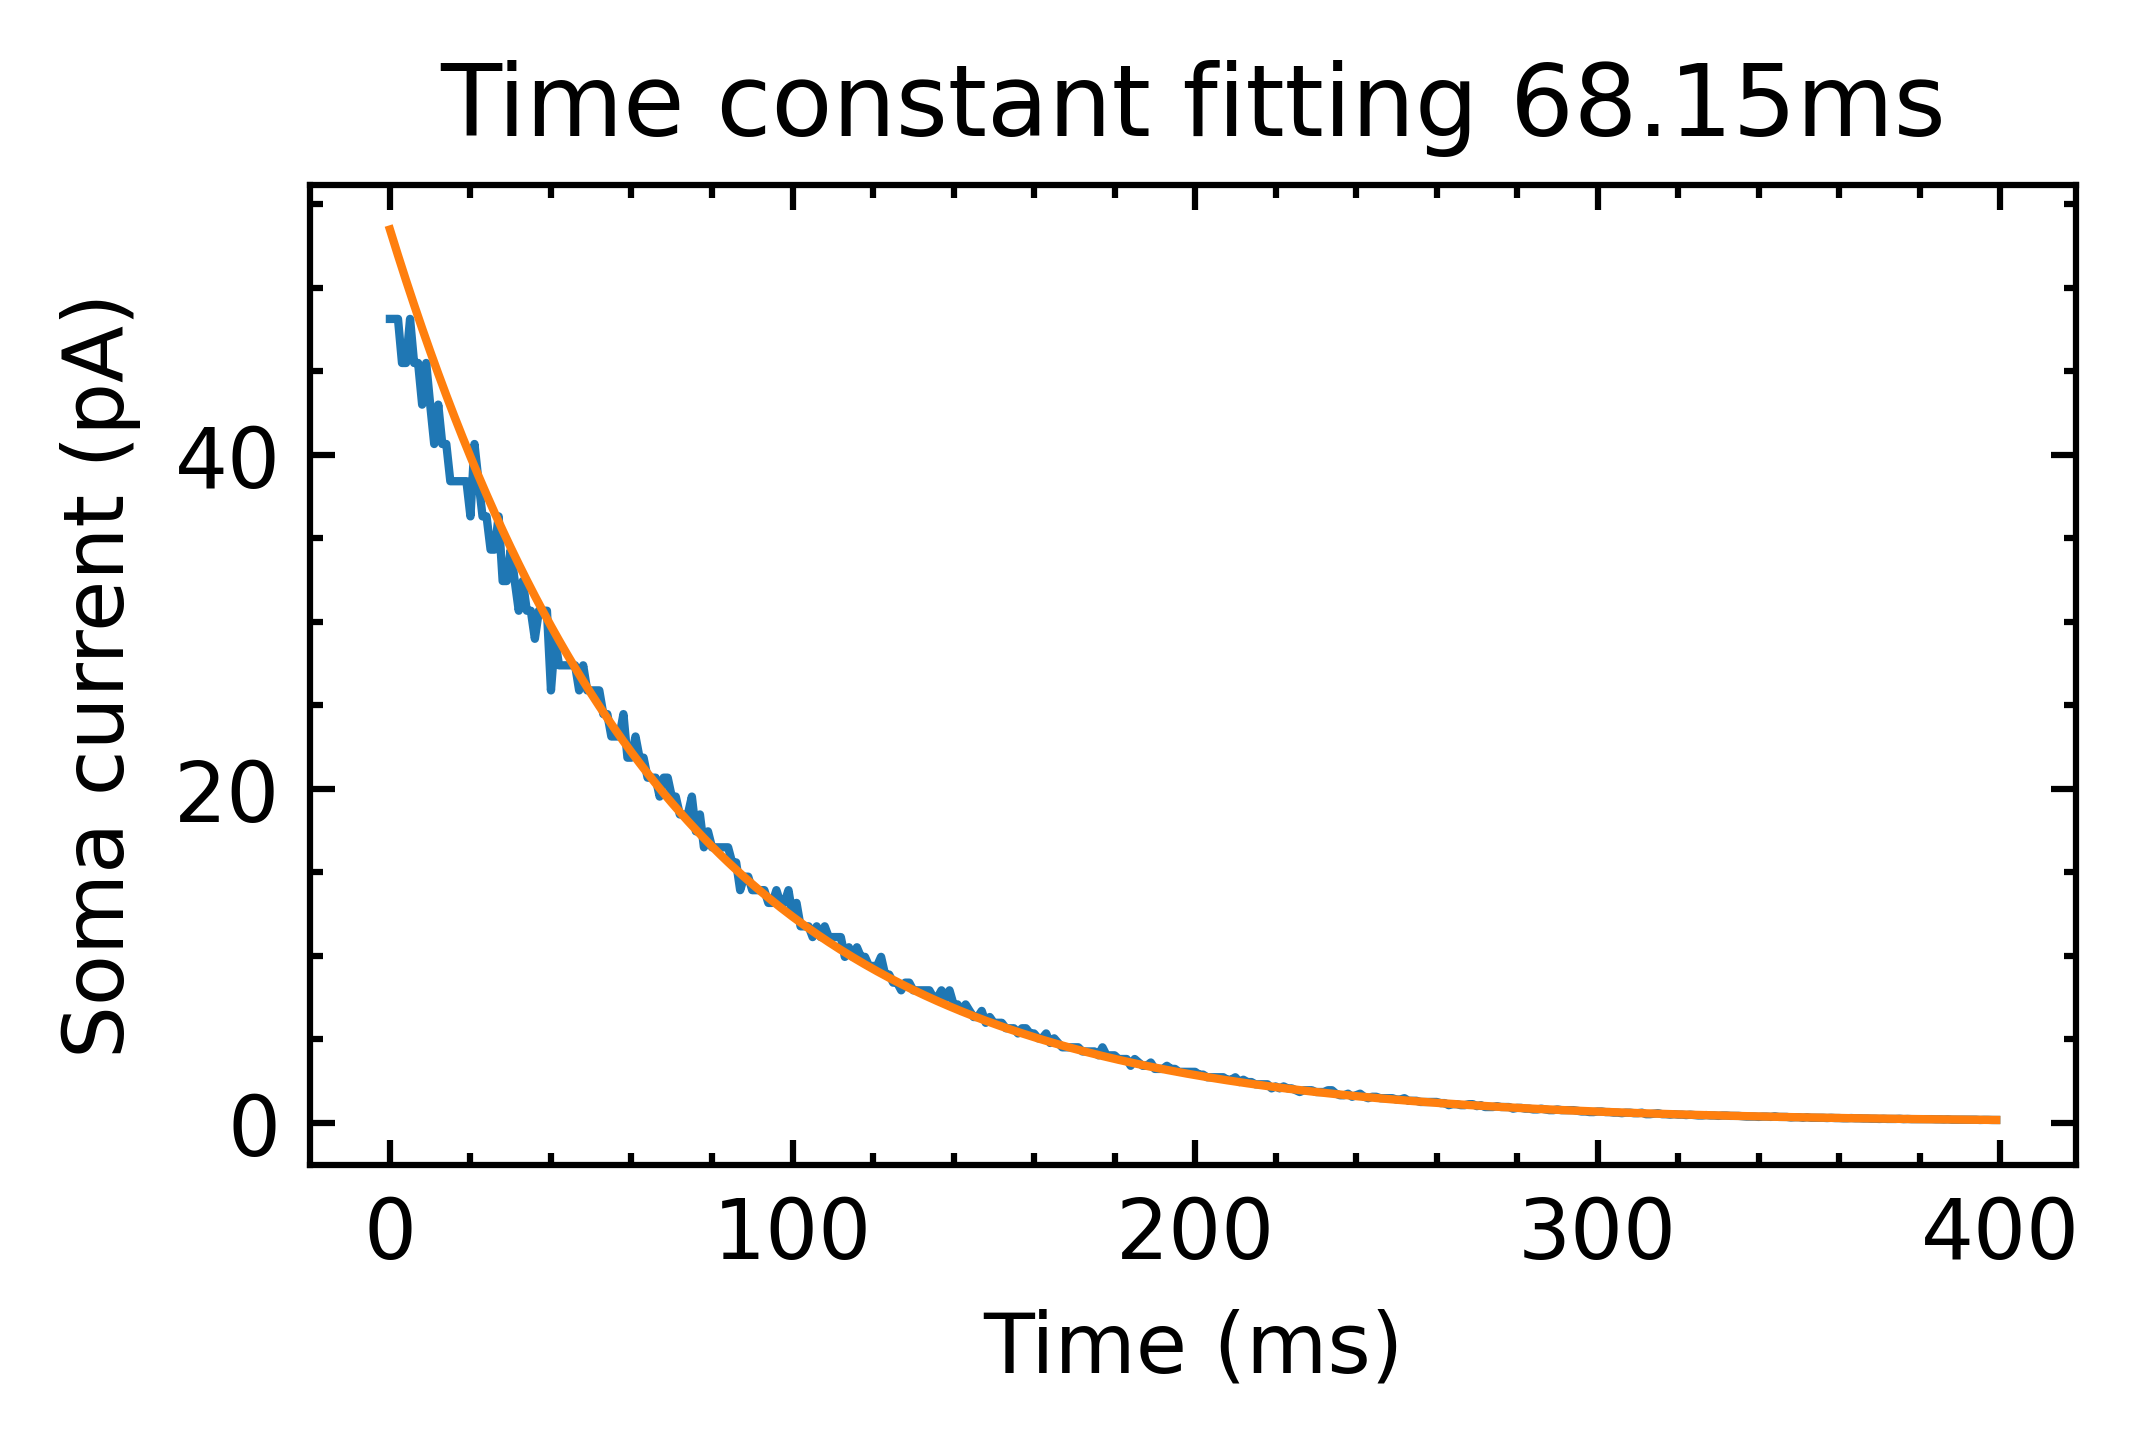

In [3]:
df = pd.read_csv(f"./records/TEK0000.CSV", header=None)
dt = float(df[1][1])
data = df[4].to_numpy() - df[4].to_numpy()[-10:].mean()

start = 1500
end = 1900

t = np.arange(len(data[start:end])) * dt * 1e3
y = DPINeuron.V2I(data[start:end])

C = 0
A, K = fit_exp_linear(t, y, C)
tau = -1 / K

with mpl.style.context("boilerplot.ieeetran"):
    fig, axs = plt.subplots(1, 1, figsize=(3.45, 2.3))
    axs.plot(t, y * 1e12)
    axs.plot(t, model_func(t, A, K, C) * 1e12)
    axs.set_title(f"Time constant fitting {tau:.2f}ms")
    axs.set_ylabel("Soma current (pA)")
    axs.set_xlabel("Time (ms)")
plt.show()

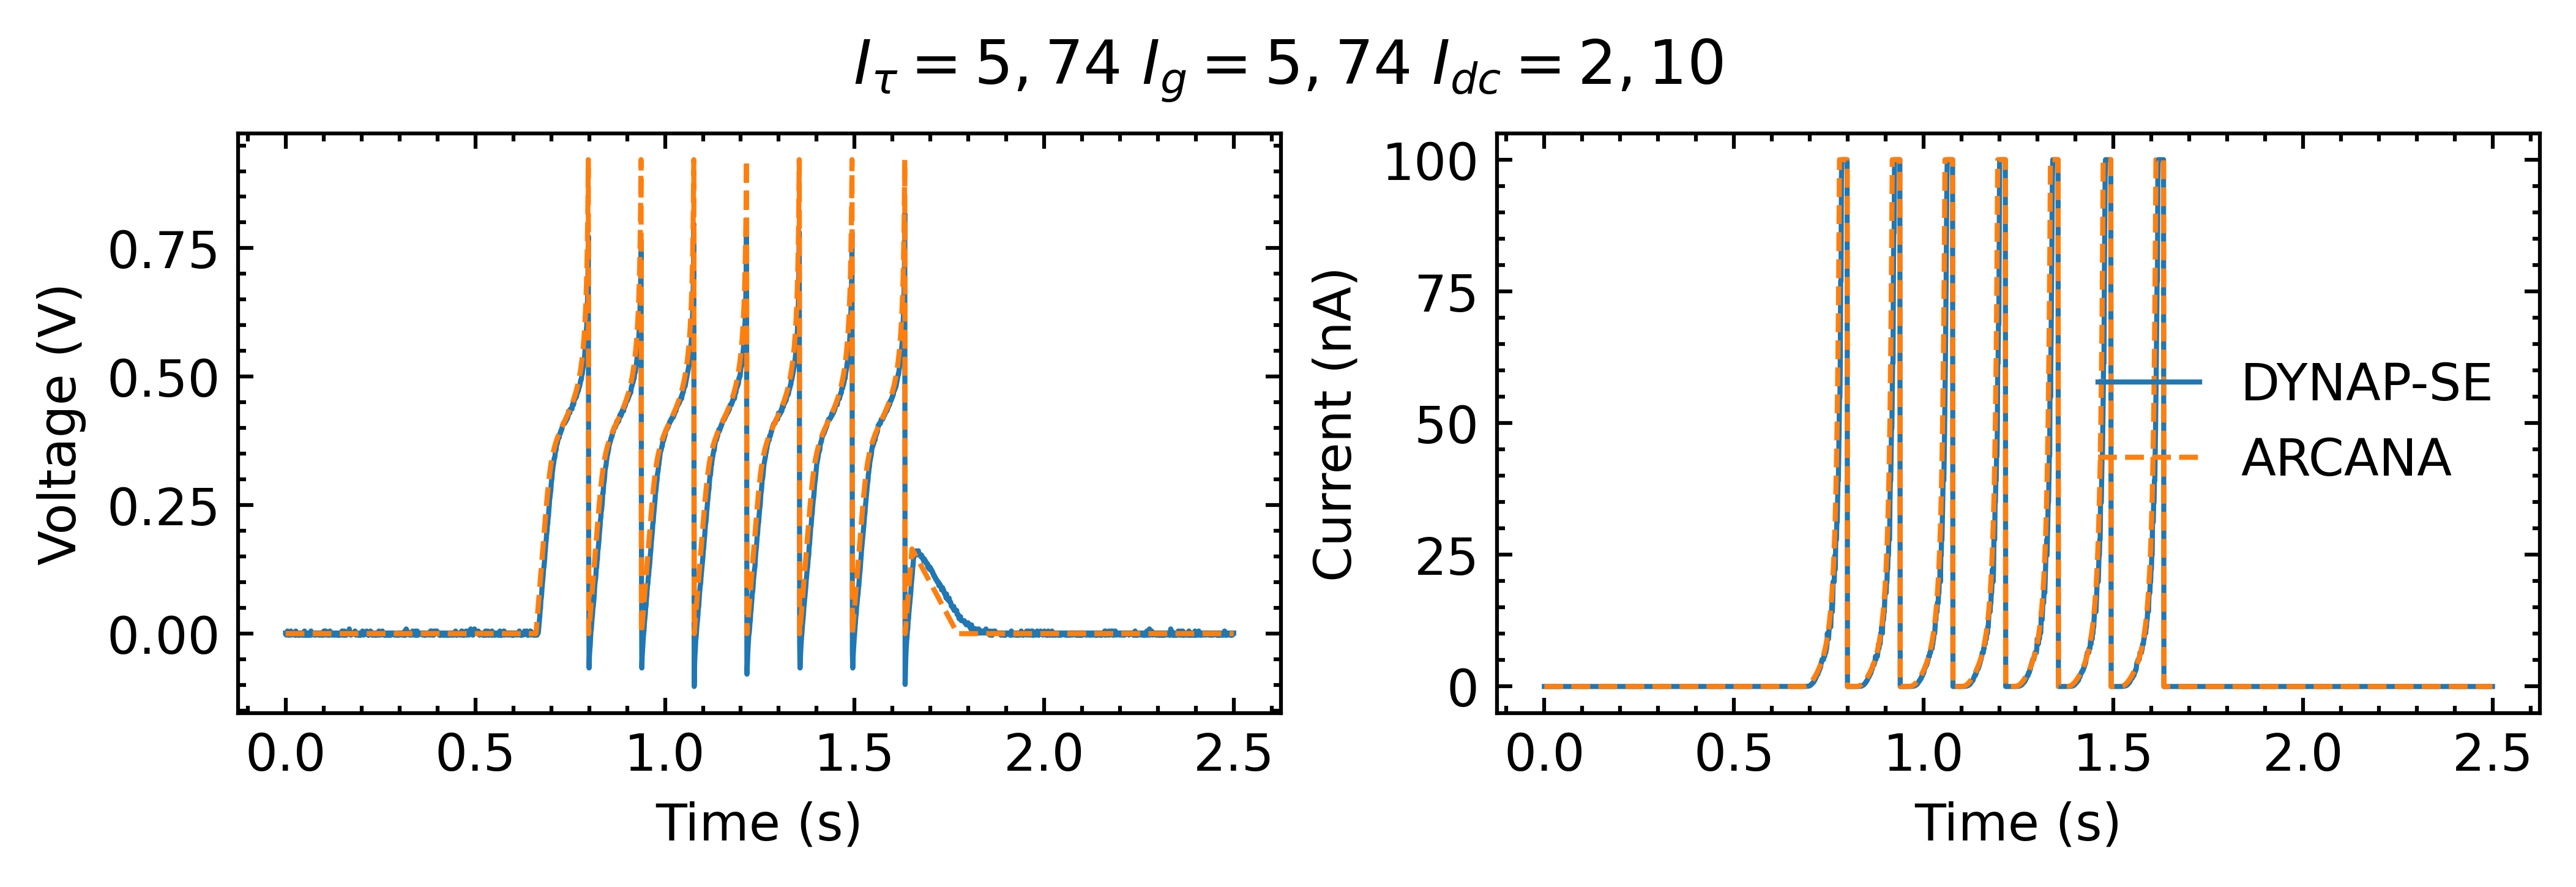

In [28]:
DPINeuron.I0 = 0.5e-13
neuron = DPINeuron(
    1,
    1,
    Itau_mem=4.1e-12,
    Igain_mem=500e-12,
    Ith=0.012,
    Idc=0e-12,
    refP=0.0,
    Ipfb_th=0e-12,
    Ipfb_norm=1.7e9,
    Itau_ampa=4e-12,
    Igain_ampa=10e-12,
    Iw_ampa=4e-12,
    dt=dt,
    train_Igain_mem=False,
    train_Itau_mem=False,
    train_Idc=False,
    train_ampa=False,
    train_gabab=False,
)
# neuron.add_mismatch(0)
# neuron.setTau(tau)

with torch.no_grad():
    neuron.eval()
    state = None
    totalImem = []
    totalVmem = []
    for t in range(2500):
        if t > (470 + 190) and t < (1430 + 222):
            neuron.Idc.data = torch.tensor(35.5e-12)
        else:
            neuron.Idc.data = torch.tensor(0.0)
        out, state = neuron(torch.zeros(1, 1), state)
        (Imem, Iampa, _, Ishunt, _, _) = state
        totalImem.append(Imem.numpy())
        totalVmem.append(neuron.I2V(Imem).numpy())
    totalImem = np.stack(totalImem)
    totalVmem = np.stack(totalVmem)

df = pd.read_csv(f"./records/TEK0007.CSV", header=None)
dt = float(df[1][1])
data = df[4].to_numpy() - df[4].to_numpy()[-10:].mean()
t = np.arange(len(data)) * dt

with mpl.style.context("boilerplot.ieeetran"):
    fig, axs = plt.subplots(1, 2, figsize=(6.9, 2.3))
    axs[0].plot(t, data, label="DYNAP-SE")
    axs[1].plot(t, np.clip(DPINeuron.V2I(data), 0, 1e-7) * 1e9, label="DYNAP-SE")
    axs[0].plot(t, totalVmem[:, 0, 0], "--", label="ARCANA")
    axs[1].plot(t, np.clip(totalImem[:, 0, 0], 0, 1e-7) * 1e9, "--", label="ARCANA")
    axs[0].set_ylabel("Voltage (V)")
    axs[0].set_xlabel("Time (s)")

    axs[1].set_ylabel("Current (nA)")
    axs[1].set_xlabel("Time (s)")
    # axs[0].set_title("Voltage")
    # axs[1].set_title("Current")
    fig.suptitle(r"$I_{\tau} = 5,74~I_g=5,74~I_{dc}=2,10$")
    plt.legend()
plt.show()
# plt.savefig('Experiments2/comparison/test1.pdf', bbox_inches='tight', dpi=300)

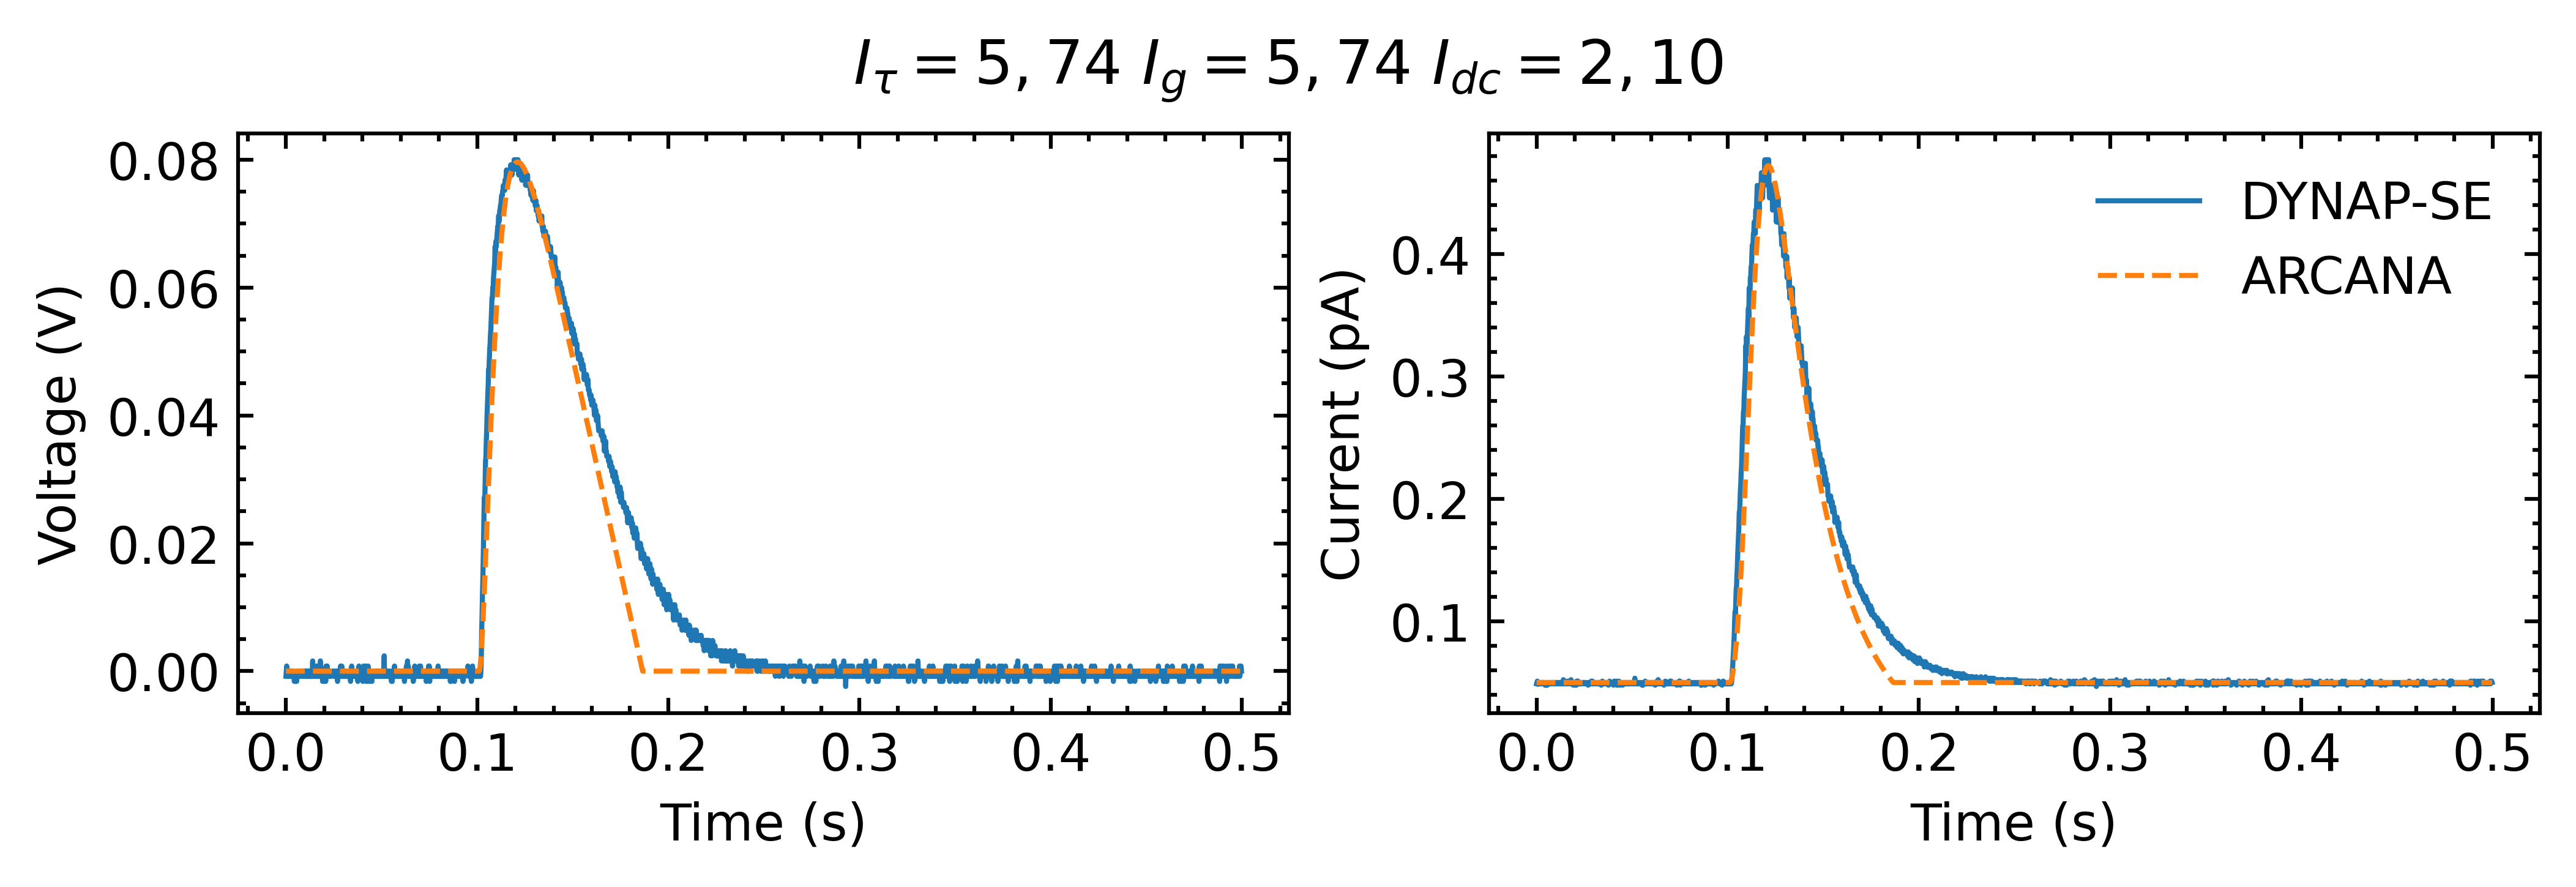

In [37]:
DPINeuron.I0 = 0.5e-13
neuron = DPINeuron(
    1,
    1,
    Itau_mem=4.0e-12,
    Igain_mem=127e-12,
    Ith=0.012,
    Idc=0e-12,
    refP=0.0,
    Ipfb_th=0e-12,
    Ipfb_norm=1.7e9,
    Itau_ampa=12.0e-12,
    Igain_ampa=10e-12,
    Iw_ampa=280e-12,
    dt=dt,
    train_Igain_mem=False,
    train_Itau_mem=False,
    train_Idc=False,
    train_ampa=False,
    train_shunt=False,
)
neuron.W_ampa.data = torch.ones(1, 1)
# neuron.add_mismatch(0)
# neuron.setTau(tau)

with torch.no_grad():
    neuron.eval()
    state = None
    totalImem = []
    totalVmem = []
    totalIampa = []
    for t in range(2500):
        if t == 490:
            input = torch.ones(1, 1)
        else:
            input = torch.zeros(1, 1)
        out, state = neuron(input, state)
        (Imem, Iampa, _, Ishunt, _, _) = state
        totalIampa.append(Iampa.numpy())
        totalImem.append(Imem.numpy())
        totalVmem.append(neuron.I2V(Imem).numpy())
    totalIampa = np.stack(totalIampa)
    totalImem = np.stack(totalImem)
    totalVmem = np.stack(totalVmem)

df = pd.read_csv(f"./records/TEK0008.CSV", header=None)
dt = float(df[1][1])
data = df[4].to_numpy() - df[4].to_numpy()[-10:].mean()
t = np.arange(len(data)) * dt

with mpl.style.context("boilerplot.ieeetran"):
    fig, axs = plt.subplots(1, 2, figsize=(6.9, 2.3))
    axs[0].plot(t, data, label="DYNAP-SE")
    axs[1].plot(t, np.clip(DPINeuron.V2I(data), 0, 1e-7) * 1e12, label="DYNAP-SE")
    axs[0].plot(t, totalVmem[:, 0, 0], "--", label="ARCANA")
    axs[1].plot(t, np.clip(totalImem[:, 0, 0], 0, 1e-7) * 1e12, "--", label="ARCANA")
    axs[0].set_ylabel("Voltage (V)")
    axs[0].set_xlabel("Time (s)")

    axs[1].set_ylabel("Current (pA)")
    axs[1].set_xlabel("Time (s)")
    # axs[0].set_title("Voltage")
    # axs[1].set_title("Current")
    fig.suptitle(r"$I_{\tau} = 5,74~I_g=5,74~I_{dc}=2,10$")
    plt.legend()
plt.show()
# plt.savefig('Experiments2/comparison/test1.pdf', bbox_inches='tight', dpi=300)

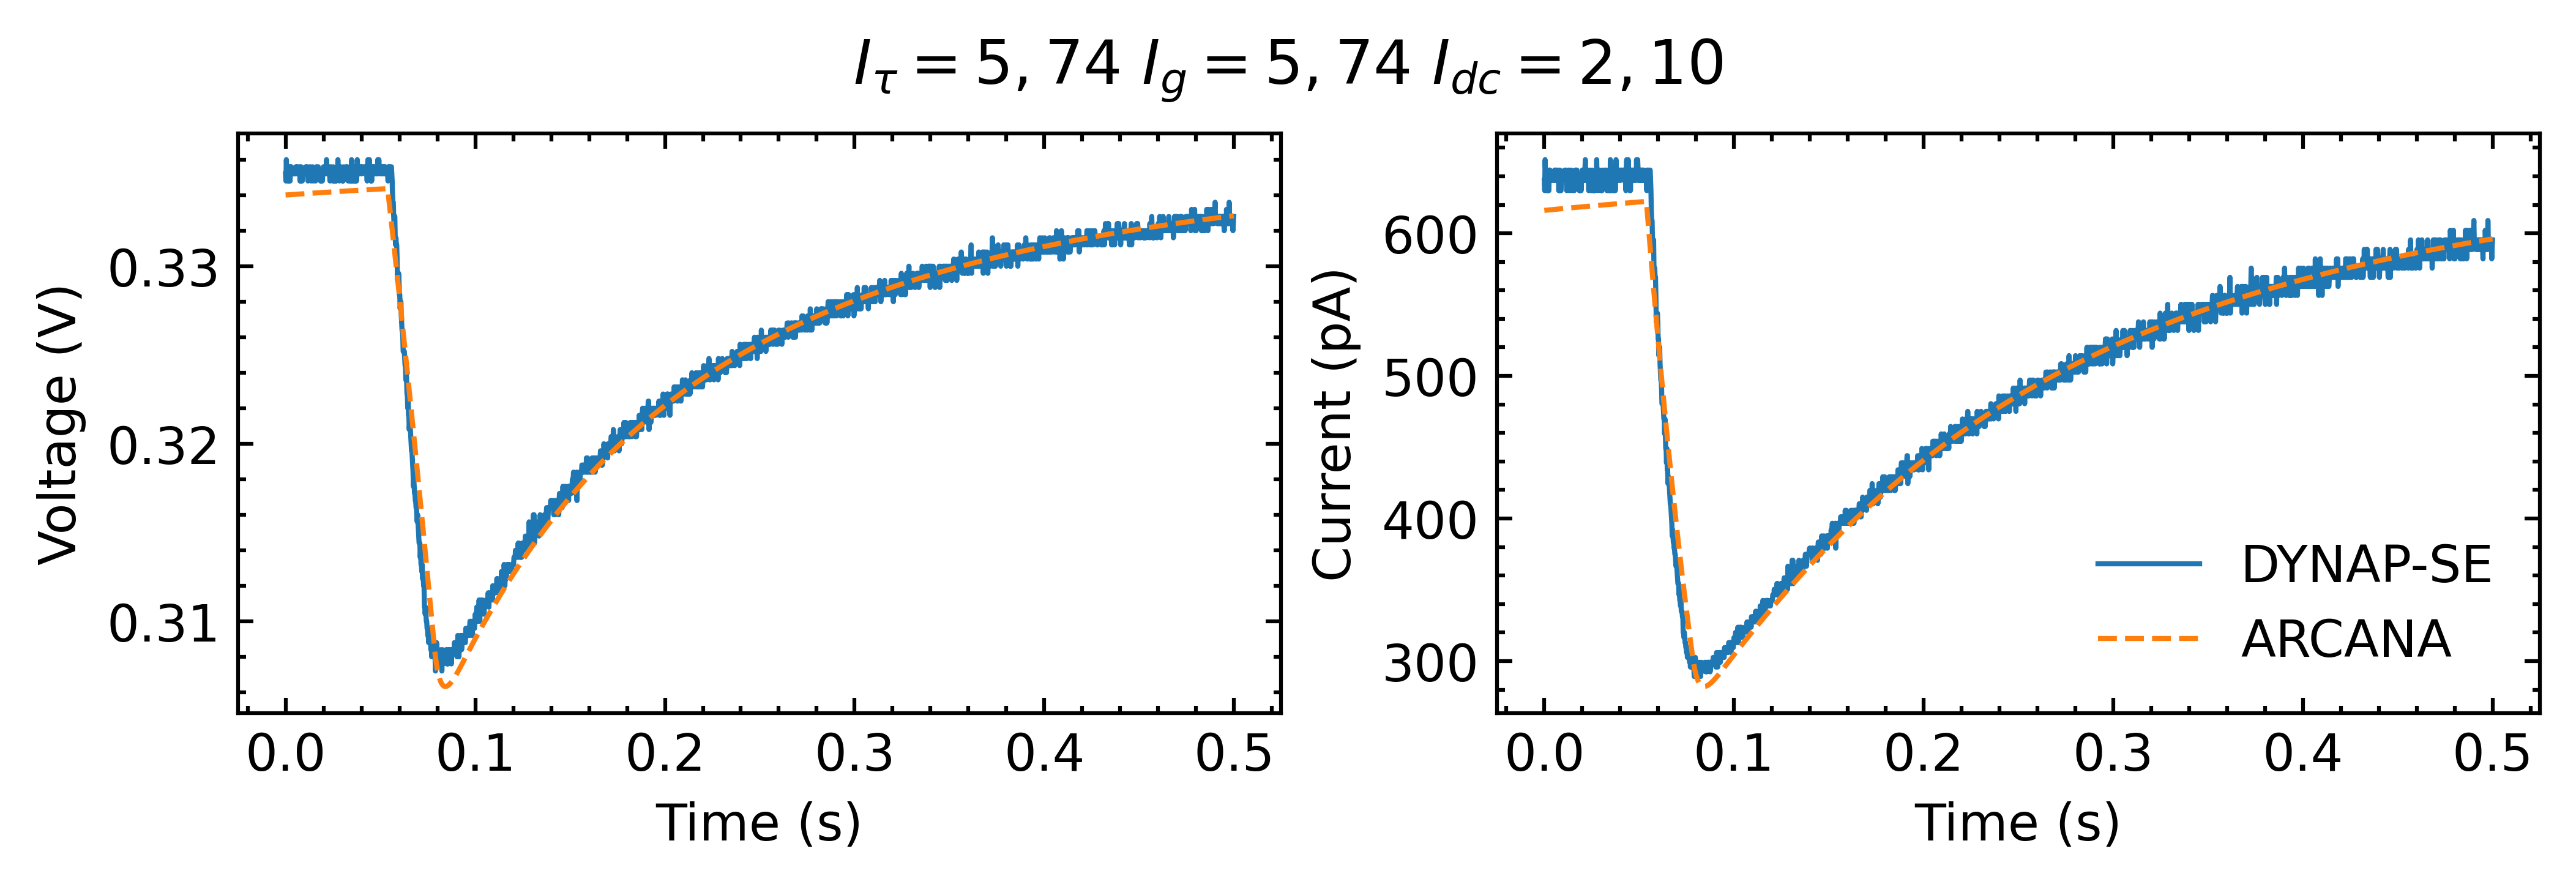

In [53]:
DPINeuron.I0 = 0.5e-13
neuron = DPINeuron(
    1,
    1,
    Itau_mem=4.1e-12,
    Igain_mem=500.0e-12,
    Ith=0.012,
    Idc=6.4e-12,
    refP=0.0,
    Ipfb_th=500.0e-12,
    Ipfb_norm=1.47e9,
    Itau_gabab=20.0e-12,
    Igain_gabab=350.0e-12,
    Iw_gabab=400e-12,
    dt=dt,
    train_Igain_mem=False,
    train_Itau_mem=False,
    train_Idc=False,
    train_ampa=False,
    train_shunt=False,
)
neuron.W_ampa.data = torch.zeros(1, 1)
neuron.W_gabab.data = torch.ones(1, 1)
# neuron.add_mismatch(0)
# neuron.setTau(tau)

with torch.no_grad():
    neuron.eval()
    state = None
    totalImem = []
    totalVmem = []
    totalIampa = []
    for t in range(5000):
        out, state = neuron(torch.zeros(1, 1), state)

    for t in range(2500):
        if t == 270:
            input = torch.ones(1, 1)
        else:
            input = torch.zeros(1, 1)
        out, state = neuron(input, state)
        (Imem, Iampa, _, Ishunt, _, _) = state
        totalIampa.append(Ishunt.numpy())
        totalImem.append(Imem.numpy())
        totalVmem.append(neuron.I2V(Imem).numpy())
    totalIampa = np.stack(totalIampa)
    totalImem = np.stack(totalImem)
    totalVmem = np.stack(totalVmem)

df = pd.read_csv(f"./records/TEK0009.CSV", header=None)
dt = float(df[1][1])
data = df[4].to_numpy() - 0.03
t = np.arange(len(data)) * dt

with mpl.style.context("boilerplot.ieeetran"):
    fig, axs = plt.subplots(1, 2, figsize=(6.9, 2.3))
    axs[0].plot(t, data, label="DYNAP-SE")
    axs[1].plot(t, np.clip(DPINeuron.V2I(data), 0, 1e-7) * 1e12, label="DYNAP-SE")
    axs[0].plot(t, totalVmem[:, 0, 0], "--", label="ARCANA")
    axs[1].plot(t, np.clip(totalImem[:, 0, 0], 0, 1e-7) * 1e12, "--", label="ARCANA")
    axs[0].set_ylabel("Voltage (V)")
    axs[0].set_xlabel("Time (s)")

    axs[1].set_ylabel("Current (pA)")
    axs[1].set_xlabel("Time (s)")
    # axs[0].set_title("Voltage")
    # axs[1].set_title("Current")
    fig.suptitle(r"$I_{\tau} = 5,74~I_g=5,74~I_{dc}=2,10$")
    plt.legend()
plt.show()
# plt.savefig('Experiments2/comparison/test1.pdf', bbox_inches='tight', dpi=300)